In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
import requests
from io import BytesIO
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train_data = tf.keras.utils.image_dataset_from_directory(
    'tomato/train',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32
).map(lambda x, y: (x / 255.0, y))

Found 10000 files belonging to 10 classes.


In [3]:
val_data = tf.keras.utils.image_dataset_from_directory(
    'tomato/val',
    labels='inferred',
    label_mode='categorical',
    image_size=(256, 256),
    batch_size=32
).map(lambda x, y: (x / 255.0, y))

Found 1000 files belonging to 10 classes.


In [4]:
conv_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(256, 256, 3), pooling='avg')
conv_base.trainable = False

In [5]:
def extract_features(data):
    features = []
    labels = []
    for images, label in data:
        try :
            feature_batch = conv_base.predict(images)
            features.append(feature_batch)
            labels.append(label)
        except Exception as e:
            print(f"Error occurred while processing {images.file_path}: {e}")
            continue
    return np.vstack(features), np.vstack(labels)

In [6]:
train_features, train_labels = extract_features(train_data)
val_features, val_labels = extract_features(val_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [7]:
print("Sample train features (first 5 rows):", train_features[:5])
print("Sample train labels (first 5):", train_labels[:5])
print("Sample validation features (first 5 rows):", val_features[:5])
print("Sample validation labels (first 5):", val_labels[:5])

Sample train features (first 5 rows): [[4.62321594e-04 6.81228610e-03 2.08242377e-03 ... 2.66729546e+00
  1.18353225e-01 2.50280410e-01]
 [4.25124657e-04 6.21821266e-03 4.67715831e-03 ... 2.26427698e+00
  6.50109291e-01 1.87129891e+00]
 [3.73405928e-04 2.05109641e-03 2.18345085e-03 ... 2.50082493e+00
  1.36371696e+00 2.93530345e-01]
 [3.05412628e-04 3.76928388e-03 5.11549320e-03 ... 2.04157090e+00
  4.88061041e-01 2.12864876e-01]
 [4.22607933e-04 5.59463259e-03 3.18119628e-03 ... 1.84373116e+00
  7.76731193e-01 1.46991336e+00]]
Sample train labels (first 5): [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]
Sample validation features (first 5 rows): [[4.5627973e-04 7.5995792e-03 4.8392760e-03 ... 3.6601596e+00
  4.5650792e-01 2.2418990e+00]
 [2.3396008e-04 3.8059826e-03 2.7730190e-03 ... 2.7097595e+00
  2.7818206e-01 2.0028081e+00]
 [4.5743253e-04 5.1885825e-03 3.3410718e

# Flatten labels for compatibility


In [8]:
train_labels = np.argmax(train_labels, axis=1)
val_labels = np.argmax(val_labels, axis=1)

In [9]:
print(train_data)
print(val_data)

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>
<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>


# Train Random Forest Classifier


In [10]:
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
rf_classifier.fit(train_features, train_labels)

RandomForestClassifier(n_estimators=200, random_state=42)

In [11]:
rf_predictions = rf_classifier.predict(val_features)
random_forest_accuracy = accuracy_score(val_labels, rf_predictions)  * 100
print("Random Forest Accuracy:", accuracy_score(val_labels, rf_predictions) * 100)
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(val_labels, rf_predictions))

Random Forest Accuracy: 88.7
Confusion Matrix (Random Forest):
[[ 97   1   0   0   0   0   0   2   0   0]
 [  3  83   5   2   2   2   2   0   1   0]
 [  1  11  83   1   2   0   2   0   0   0]
 [  0   0   2  85   0   1   7   1   4   0]
 [  3   4   2   3  84   0   3   0   0   1]
 [  0   0   0   5   0  89   4   0   1   1]
 [  1   1   0   0   3  12  79   0   1   3]
 [  3   0   0   0   0   1   0  96   0   0]
 [  0   0   0   0   0   0   0   0 100   0]
 [  0   0   0   0   0   0   8   0   1  91]]


# Simple CNN

In [12]:
def create_simple_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

## Training the model with 5 epoch

In [13]:
simple_cnn = create_simple_cnn()
simple_cnn.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
simple_cnn.fit(train_data, epochs=5, validation_data=val_data, callbacks=[EarlyStopping(patience=3)])

Epoch 1/5


c:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 261s 822ms/step - accuracy: 0.5781 - loss: 1.8644 - val_accuracy: 0.1760 - val_loss: 7.9181
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 241s 770ms/step - accuracy: 0.7966 - loss: 0.6274 - val_accuracy: 0.7520 - val_loss: 0.8041
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 274s 876ms/step - accuracy: 0.8640 - loss: 0.4212 - val_accuracy: 0.8500 - val_loss: 0.5954
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 260s 828ms/step - accuracy: 0.9011 - loss: 0.2934 - val_accuracy: 0.8470 - val_loss: 0.6061
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 266s 851ms/step - accuracy: 0.9201 - loss: 0.2472 - val_accuracy: 0.7790 - val_loss: 0.9414


In [14]:
simple_cnn_eval = simple_cnn.evaluate(val_data)
simple_cnn_accuracy = simple_cnn_eval[1] * 100
print("Simple CNN Accuracy:", simple_cnn_eval[1] * 100)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.7788 - loss: 0.9898
Simple CNN Accuracy: 77.89999842643738


In [15]:
def create_densenet_cnn():
    model = Sequential([
        conv_base,
        BatchNormalization(),
        Dense(256, activation='relu'),
        Dropout(0.35),
        BatchNormalization(),
        Dense(120, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [16]:
densenet_cnn = create_densenet_cnn()
densenet_cnn.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
densenet_cnn.fit(train_data, epochs=17, validation_data=val_data, callbacks=[EarlyStopping(patience=3)])

Epoch 1/17


313/313 ━━━━━━━━━━━━━━━━━━━━ 452s 1s/step - accuracy: 0.3680 - loss: 1.8856 - val_accuracy: 0.7630 - val_loss: 0.8990
Epoch 2/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.7585 - loss: 0.7719 - val_accuracy: 0.8310 - val_loss: 0.5271
Epoch 3/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step - accuracy: 0.8334 - loss: 0.5340 - val_accuracy: 0.8690 - val_loss: 0.3944
Epoch 4/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.8694 - loss: 0.4033 - val_accuracy: 0.8850 - val_loss: 0.3323
Epoch 5/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 369s 1s/step - accuracy: 0.8972 - loss: 0.3324 - val_accuracy: 0.8970 - val_loss: 0.2907
Epoch 6/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 366s 1s/step - accuracy: 0.9083 - loss: 0.2841 - val_accuracy: 0.9100 - val_loss: 0.2608
Epoch 7/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - accuracy: 0.9281 - loss: 0.2386 - val_accuracy: 0.9190 - val_loss: 0.2349
Epoch 8/17
313/313 ━━━━━━━━━━━━━━━━━━━━ 369s 1s/step - accuracy: 0.9307 - loss: 0.2115 - val_accuracy: 0.929

In [17]:
densenet_cnn_eval = densenet_cnn.evaluate(val_data)
print("DenseNet CNN Accuracy:", densenet_cnn_eval[1] * 100)
densenet_cnn_accuracy = densenet_cnn_eval[1] * 100

32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9527 - loss: 0.1467
DenseNet CNN Accuracy: 95.70000171661377


In [18]:
def predict_from_url(url, model, model_type='densenet'):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).resize((256, 256))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

    if model_type == 'rf':
        features = conv_base.predict(img_array)
        prediction = model.predict(features)
        predicted_label = np.argmax(prediction)
    elif model_type == 'simple_cnn':
        prediction = model.predict(img_array)
        predicted_label = np.argmax(prediction)
    elif model_type == 'densenet':
        prediction = model.predict(img_array)
        predicted_label = np.argmax(prediction)

    return predicted_label

In [19]:
class_labels = [
    "Bacterial Spot", 
    "Early Blight",   
    "Healthy",   
    "Late Blight",
    "Leaf Mold",
    "Septoria leaf spot",
    "Two Spotted Spider mite",
    "Target spot",
    "mosaic virus",
    "yellow leaf virus"
]

In [29]:
example_url = "https://imgs.search.brave.com/uz3gL-xyiTp9T-ffOfowK0tgQKpmUfNZeB9aiXebHYY/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9wbGFu/dGNhcmV0b2RheS5j/b20vd3AtY29udGVu/dC91cGxvYWRzL3Rv/bWF0by15ZWxsb3ct/bGVhdmVzLTEyMDAt/NjMwLUZCLTAzMzEy/MDE5LW1pbi5qcGc"
predicted_rf_disease = predict_from_url(example_url, rf_classifier, model_type='rf')
predicted_simple_cnn_disease = predict_from_url(example_url, simple_cnn, model_type='simple_cnn')
predicted_densenet_disease = predict_from_url(example_url, densenet_cnn, model_type='densenet')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [30]:
predicted_rf_disease_name = class_labels[predicted_rf_disease]
predicted_simple_cnn_disease_name = class_labels[predicted_simple_cnn_disease]
predicted_densenet_disease_name = class_labels[predicted_densenet_disease]

In [31]:
print("Predicted Disease Label (Random Forest):", predicted_rf_disease_name)
print("Predicted Disease Label (Simple CNN):", predicted_simple_cnn_disease_name)
print("Predicted Disease Label (DenseNet CNN):", predicted_densenet_disease_name)

Predicted Disease Label (Random Forest): Bacterial Spot
Predicted Disease Label (Simple CNN): Healthy
Predicted Disease Label (DenseNet CNN): Healthy


C:\Users\tiger\AppData\Local\Temp\ipykernel_16676\3238778116.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='Oranges_d')


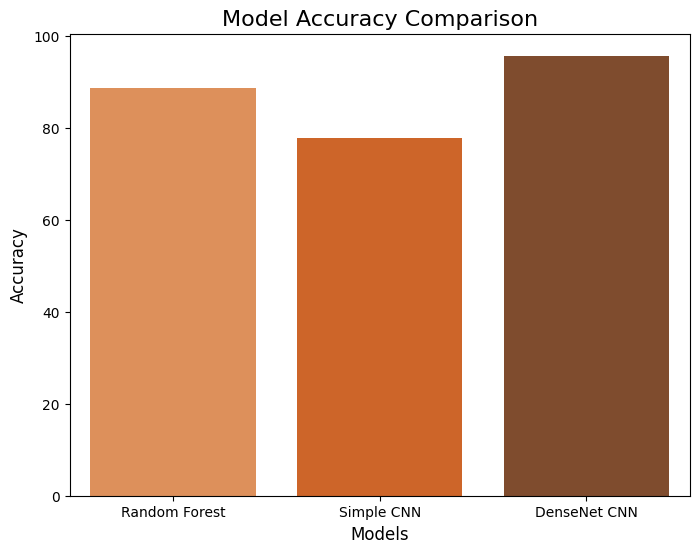

In [23]:
model_names = ['Random Forest', 'Simple CNN', 'DenseNet CNN']
accuracies = [random_forest_accuracy, simple_cnn_accuracy, densenet_cnn_accuracy]  # Replace with actual accuracy values

# Create a bar plot for model accuracies
plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, palette='Oranges_d')

# Add labels and title
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Show the plot
plt.show()

In [24]:
densenet_predictions = np.argmax(densenet_cnn.predict(val_data), axis=1)
simple_cnn_predictions = np.argmax(simple_cnn.predict(val_data), axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step


In [25]:
densenet_cm = confusion_matrix(val_labels, densenet_predictions)
print(densenet_cm)

[[10  8 16  8 11  9  9 13  7  9]
 [13  9 10  8  4  9 15  9 14  9]
 [16 10 14 14  7  6  7 10 10  6]
 [10 10 11  5  6 12 10  7 15 14]
 [11  6 13  9 16  6  8 10  8 13]
 [ 5  8 11 13 11 12 10 13  9  8]
 [ 8 11  8  7 11  9 12 16  9  9]
 [11 12 10 12  8  8  6  8 16  9]
 [10 15  8 11 11  7  6  9  8 15]
 [ 7  9  6 11 12 21 11  5  9  9]]


In [26]:
simple_cnn_cm = confusion_matrix(val_labels, simple_cnn_predictions)
print(simple_cnn_cm)

[[17  5 13  7  9 16  6  9 11  7]
 [12  7 17  9  5  8  5 14  8 15]
 [14  7 12 10 10 14  3 10  7 13]
 [ 9  5 19 11  8 14  2 18  4 10]
 [11  7 12 12 17 11  3 16  4  7]
 [11  5 12  9 11 15  4 12  4 17]
 [11  9 14  8 14 16  5  9  4 10]
 [ 8  4 15  6 14 16  2 14  6 15]
 [14 10 16  4 14 18  4  7  8  5]
 [10  7 12  9  8 14  2 13 14 11]]


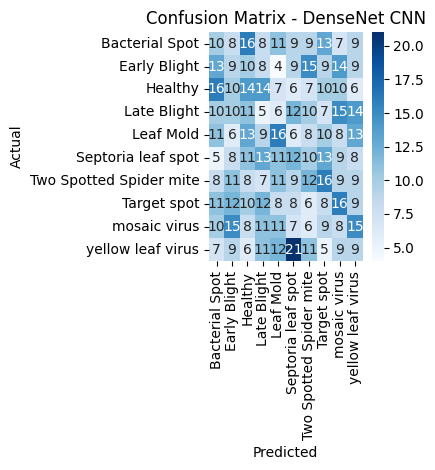

In [27]:
plt.subplot(1, 2, 1)
sns.heatmap(densenet_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - DenseNet CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

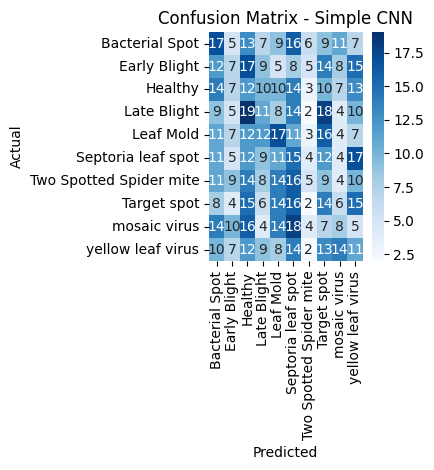

In [28]:
plt.subplot(1, 2, 2)
sns.heatmap(simple_cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Simple CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()